In [92]:
import pm4py
import warnings

warnings.filterwarnings("ignore")

In [93]:
log = pm4py.read_xes("../data/control-flow/control_flow_001.xes")
log.head(5)

parsing log, completed traces :: 100%|██████████| 1000/1000 [00:00<00:00, 17588.32it/s]


,event:id,concept:name,start_timestamp,time:timestamp,event:duration_min,org:resource,org:role,case:concept:name,case:case_type,case:amount,case:region
0,evt_00000001,c,2020-01-01 01:14:44.646407+00:00,2020-01-01 01:25:13.327249+00:00,10.478014,res_003,role_01,case_000001,type_03,874.16,DE-BW
1,evt_00000002,a,2020-01-01 01:25:32.244869+00:00,2020-01-01 01:34:52.378828+00:00,9.335566,res_005,role_01,case_000001,type_03,874.16,DE-BW
2,evt_00000003,b,2020-01-01 01:35:18.731225+00:00,2020-01-01 01:45:35.879176+00:00,10.285799,res_005,role_01,case_000001,type_03,874.16,DE-BW
3,evt_00000004,c,2020-01-01 01:38:41.586978+00:00,2020-01-01 01:55:41.728712+00:00,17.002362,res_003,role_01,case_000002,type_02,856.88,DE-HE
4,evt_00000005,a,2020-01-01 01:57:31.534941+00:00,2020-01-01 02:15:00.481385+00:00,17.482441,res_004,role_02,case_000002,type_02,856.88,DE-HE


In [94]:
variants = pm4py.get_variants(log)

print(variants)

{('c', 'a', 'b'): 239, ('c', 'a', 'b', 'd', 'b'): 242, ('c', 'a', 'e', 'b'): 423, ('c', 'a', 'e', 'b', 'd', 'b'): 96}


In [95]:
print(len(variants))

4


In [96]:
print(len(log["concept:name"]))
#print(len(log1["concept:name"]))

4195


In [97]:
case_ids = sorted(log["case:concept:name"].unique())

print("log case ids:", len(case_ids))
print(case_ids)

log case ids: 1000
['case_000001', 'case_000002', 'case_000003', 'case_000004', 'case_000005', 'case_000006', 'case_000007', 'case_000008', 'case_000009', 'case_000010', 'case_000011', 'case_000012', 'case_000013', 'case_000014', 'case_000015', 'case_000016', 'case_000017', 'case_000018', 'case_000019', 'case_000020', 'case_000021', 'case_000022', 'case_000023', 'case_000024', 'case_000025', 'case_000026', 'case_000027', 'case_000028', 'case_000029', 'case_000030', 'case_000031', 'case_000032', 'case_000033', 'case_000034', 'case_000035', 'case_000036', 'case_000037', 'case_000038', 'case_000039', 'case_000040', 'case_000041', 'case_000042', 'case_000043', 'case_000044', 'case_000045', 'case_000046', 'case_000047', 'case_000048', 'case_000049', 'case_000050', 'case_000051', 'case_000052', 'case_000053', 'case_000054', 'case_000055', 'case_000056', 'case_000057', 'case_000058', 'case_000059', 'case_000060', 'case_000061', 'case_000062', 'case_000063', 'case_000064', 'case_000065', 'case

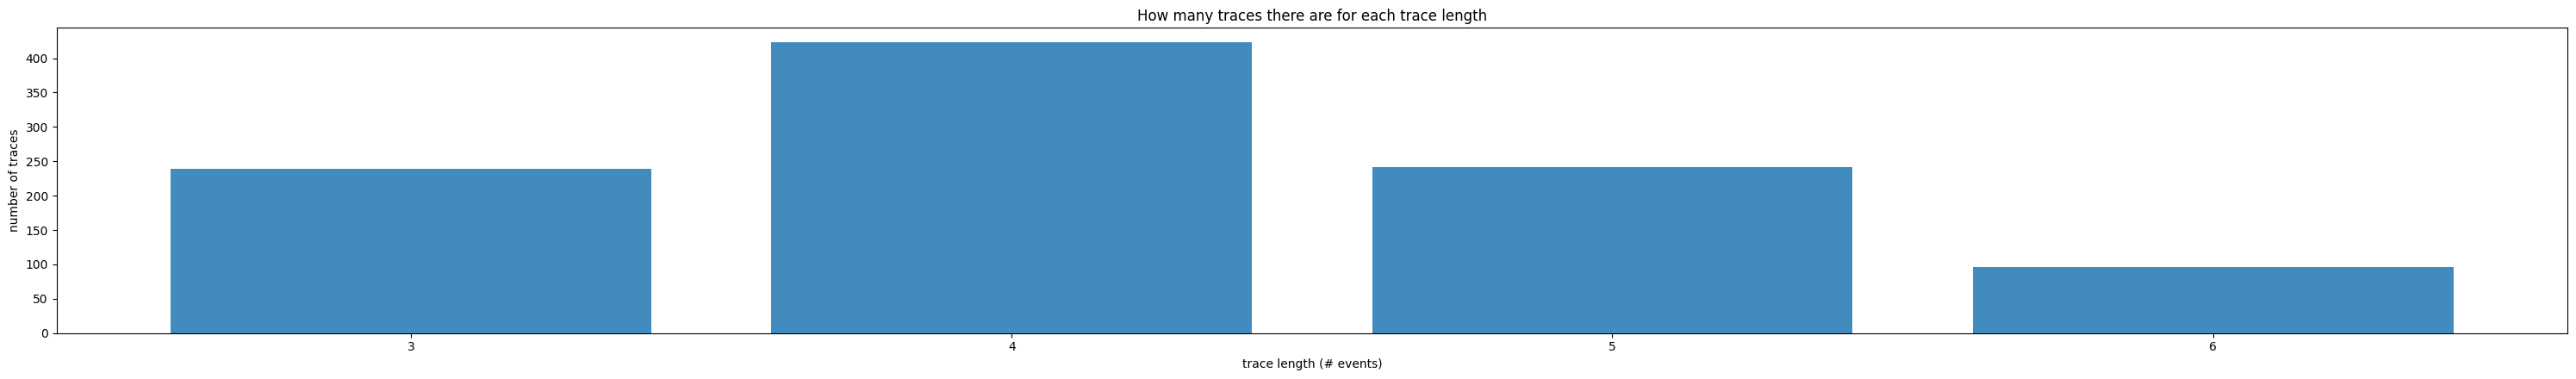

In [98]:
import matplotlib.pyplot as plt
import numpy as np

trace_length_distributions = {
    "log": log.groupby("case:concept:name").size().value_counts().sort_index()
}

all_lengths = sorted({
    length
    for distribution in trace_length_distributions.values()
    for length in distribution.index
})

x = np.arange(len(all_lengths))
bar_width = 0.8 / len(trace_length_distributions)

fig, ax = plt.subplots(figsize=(30, 4.5))
for idx, (label, distribution) in enumerate(trace_length_distributions.items()):
    heights = [distribution.get(length, 0) for length in all_lengths]
    offsets = x + (idx - (len(trace_length_distributions) - 1) / 2) * bar_width
    ax.bar(offsets, heights, width=bar_width, label=label, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_lengths)
ax.set_xlabel("trace length (# events)")
ax.set_ylabel("number of traces")
ax.set_title("How many traces there are for each trace length")
if len(trace_length_distributions) > 1:
    ax.legend()
plt.tight_layout()

In [99]:
import json

with open("../data/control-flow/control_flow_001.xes.metadata.json") as f:
    metadata = json.load(f)

print(metadata["drifts"])

[{'affected_columns': ['concept:name'], 'change_details': {'activities_added': ['e'], 'activities_deleted': [], 'activities_moved': [], 'operator_swaps': [], 'variant_count_after': 2, 'variant_count_before': 2, 'variant_counts_by_version': [2, 2]}, 'change_point_timestamp': '2020-01-28T22:15:15.054181+00:00', 'drift_id': 'd01', 'drift_type': 'sudden', 'overlap_window_end': None, 'overlap_window_start': None, 'perspective': 'control_flow', 'subtype': 'tree_mutation'}]


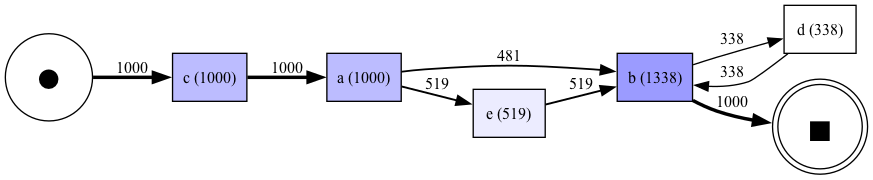

In [100]:
dfg, sa, ea = pm4py.discover_directly_follows_graph(log)
pm4py.view_dfg(dfg, sa, ea)